<a href="https://colab.research.google.com/github/omkulawade03/Dataset/blob/main/Special_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import core packages for data tables and charts
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving deliveries.csv to deliveries (1).csv


In [ ]:
filepath = "/content/deliveries.csv"
df_ipl = pd.read_csv("deliveries.csv")

In [ ]:
# View the top 5 records to inspect individual ball variables
df_ipl.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [ ]:
# Look at total dimension shape of the delivery logs
df_ipl.shape

(260920, 17)

In [ ]:
# Print out the array of column names
df_ipl.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')

In [ ]:
# Confirm structural data types for text and numbers
df_ipl.dtypes

,0
match_id,int64
inning,int64
batting_team,object
bowling_team,object
over,int64
ball,int64
batter,object
bowler,object
non_striker,object
batsman_runs,int64


In [ ]:
# Find total missing data rows across every parameter
df_ipl.isnull().sum()

,0
match_id,0
inning,0
batting_team,0
bowling_team,0
over,0
ball,0
batter,0
bowler,0
non_striker,0
batsman_runs,0


In [ ]:
# Check numerical summaries for runs scored and wickets
df_ipl.describe()

,match_id,inning,over,ball,batsman_runs,extra_runs,total_runs,is_wicket
count,2.609200e+05,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000
mean,9.070665e+05,1.483531,9.197677,3.624486,1.265001,0.067806,1.332807,0.049632
std,3.679913e+05,0.502643,5.683484,1.814920,1.639298,0.343265,1.626416,0.217184
min,3.359820e+05,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,5.483340e+05,1.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,9.809670e+05,1.000000,9.000000,4.000000,1.000000,0.000000,1.000000,0.000000
75%,1.254066e+06,2.000000,14.000000,5.000000,1.000000,0.000000,1.000000,0.000000
max,1.426312e+06,6.000000,19.000000,11.000000,6.000000,7.000000,7.000000,1.000000


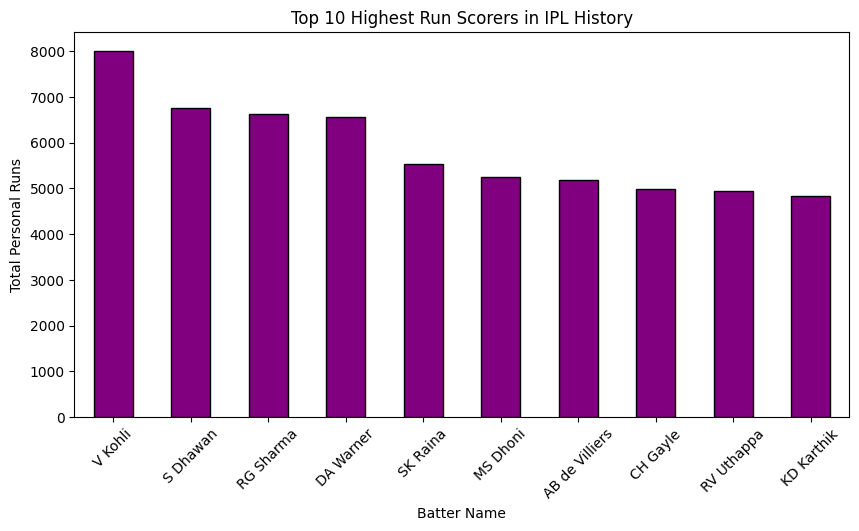

In [ ]:
# Set figure dimensions
plt.figure(figsize=(10, 5))

# Group by batter, sum up their runs, get top 10, and plot a vertical bar chart
top_batters = (
    df_ipl.groupby("batter")["batsman_runs"].sum().sort_values(ascending=False).head(10)
)
top_batters.plot(kind="bar", color="purple", edgecolor="black")

plt.title("Top 10 Highest Run Scorers in IPL History")
plt.xlabel("Batter Name")
plt.ylabel("Total Personal Runs")
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_486/1858101583.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="batsman_runs", data=df_ipl, palette="viridis")


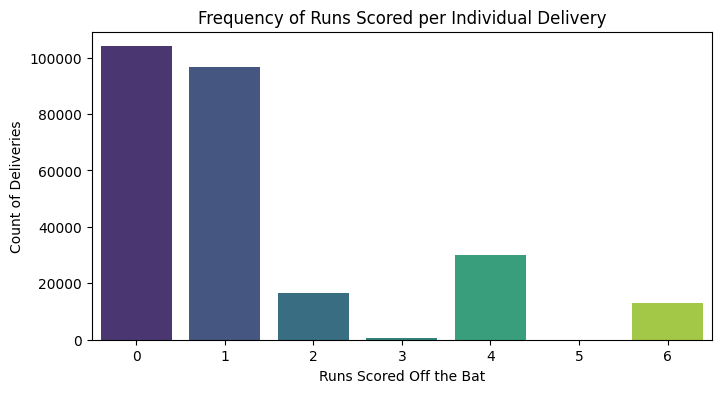

In [ ]:
# Set figure dimensions
plt.figure(figsize=(8, 4))

# Count the frequency of different run numbers scored on individual balls
sns.countplot(x="batsman_runs", data=df_ipl, palette="viridis")

plt.title("Frequency of Runs Scored per Individual Delivery")
plt.xlabel("Runs Scored Off the Bat")
plt.ylabel("Count of Deliveries")
plt.show()

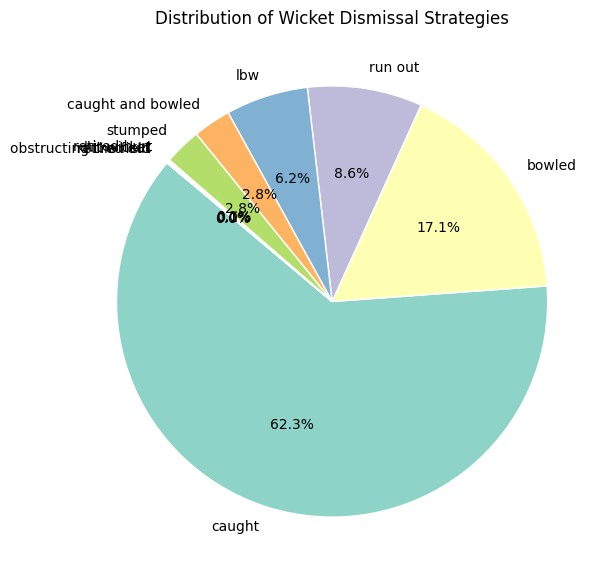

In [ ]:
# Set figure dimensions
plt.figure(figsize=(7, 7))

# Filter down to entries where a wicket fell and isolate valid types
wicket_events = df_ipl[df_ipl["is_wicket"] == 1]
dismissal_shares = wicket_events["dismissal_kind"].value_counts()

# Plot a pie chart using a custom wedge properties dictionary to prevent rendering issues
dismissal_shares.plot(
    kind="pie",
    autopct="%1.1f%%",
    cmap="Set3",
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1},
)

plt.title("Distribution of Wicket Dismissal Strategies")
plt.ylabel("")  # Clear out default vertical axis labels
plt.show()

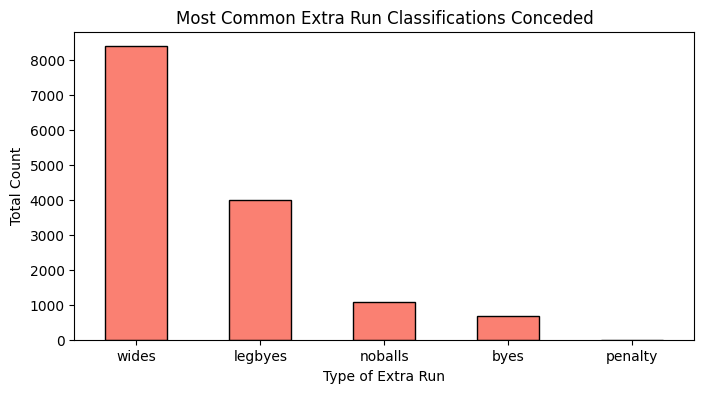

In [ ]:
# Set figure dimensions
plt.figure(figsize=(8, 4))

# Count the categorical distribution of extras type codes
df_ipl["extras_type"].value_counts().plot(
    kind="bar", color="salmon", edgecolor="black"
)

plt.title("Most Common Extra Run Classifications Conceded")
plt.xlabel("Type of Extra Run")
plt.ylabel("Total Count")
plt.xticks(rotation=0)
plt.show()

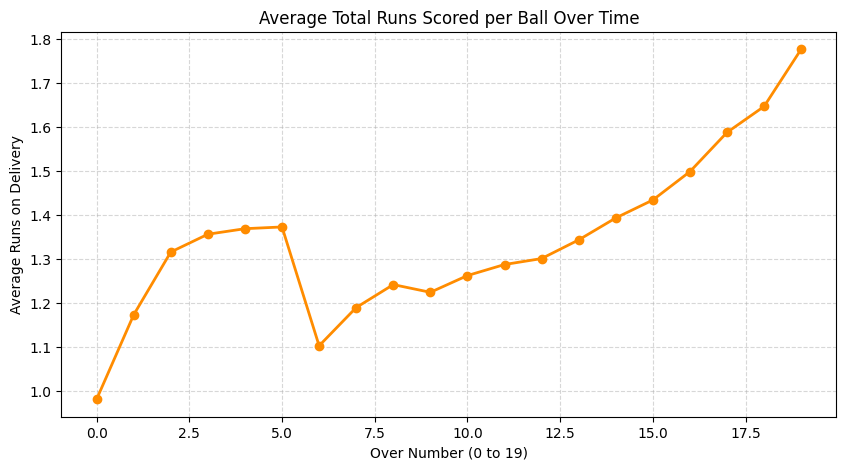

In [ ]:
# Set figure dimensions
plt.figure(figsize=(10, 5))

# Calculate average total runs scored on a delivery for every over (0 through 19)
run_progression = df_ipl.groupby("over")["total_runs"].mean()

# Plot a simple progression line plot
plt.plot(
    run_progression.index,
    run_progression.values,
    marker="o",
    color="darkorange",
    linewidth=2,
)

plt.title("Average Total Runs Scored per Ball Over Time")
plt.xlabel("Over Number (0 to 19)")
plt.ylabel("Average Runs on Delivery")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

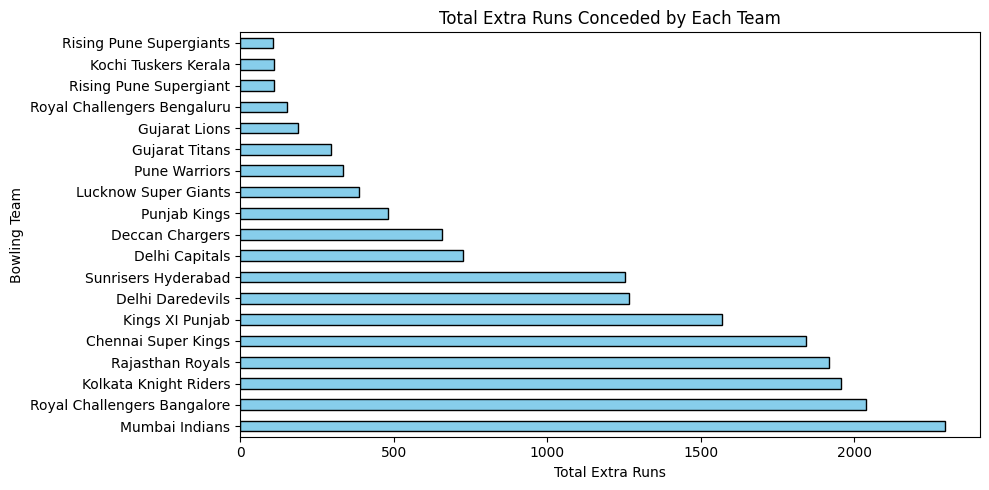

In [ ]:
# Set figure dimensions
plt.figure(figsize=(10, 5))

# Group by the bowling team and sum up all the extra runs they gave away
team_extras = (
    df_ipl.groupby("bowling_team")["extra_runs"]
    .sum()
    .sort_values(ascending=False)
)

# Plot a horizontal bar chart so long team names are easily readable
team_extras.plot(kind="barh", color="skyblue", edgecolor="black")

plt.title("Total Extra Runs Conceded by Each Team")
plt.xlabel("Total Extra Runs")
plt.ylabel("Bowling Team")
plt.tight_layout()  # Keeps labels from getting cut off
plt.show()

/tmp/ipykernel_486/1279502099.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


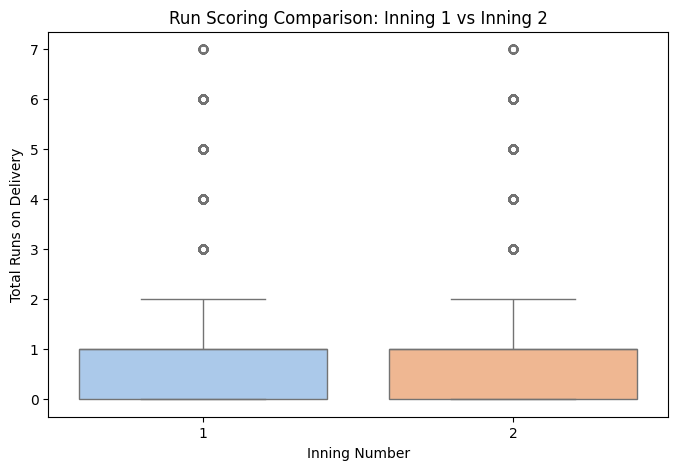

In [ ]:
# Set figure dimensions
plt.figure(figsize=(8, 5))

# Filter dataset to only look at standard 1st and 2nd innings
clean_innings_df = df_ipl[df_ipl["inning"].isin([1, 2])]

# Create a boxplot comparing total runs per ball for both innings
sns.boxplot(
    x="inning", y="total_runs", data=clean_innings_df, palette="pastel"
)

plt.title("Run Scoring Comparison: Inning 1 vs Inning 2")
plt.xlabel("Inning Number")
plt.ylabel("Total Runs on Delivery")
plt.show()

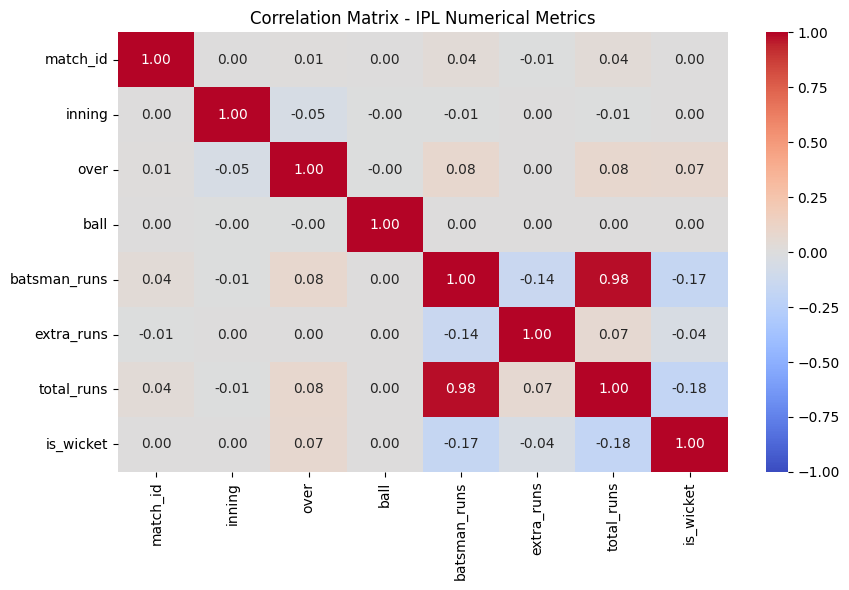

In [ ]:
# Import packages inside the cell to prevent potential NameErrors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Select only the numerical columns from the IPL dataset
# This isolates runs, innings, over, ball counts, and wicket flags
numeric_ipl = df_ipl.select_dtypes(include=[np.number])

# 2. Build the correlation heatmap matrix
plt.figure(figsize=(9, 6))
sns.heatmap(numeric_ipl.corr(), annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)

plt.title("Correlation Matrix - IPL Numerical Metrics")
plt.tight_layout()
plt.show()